### Predictive Model
* Gene expression: log2 normalization, top 10% expression levels and variance -> Struggling to integrate this
* Mutation data: Missense|Nonsense|Frame_Shift|Splice|In_Frame counts per patient per gene (NS mutations), taking top 10 IntOGen genes
* Metatdata: age at diagnosis, gender, stage, histological grade
* Predict: DFI - predict likelihood of recurrence within 2 years
* Check: ROC_AUC, balance classes, balanced accuracy -> avoid overfitting

In [2]:
import pandas as pd
import numpy as np

# Load data
expr = pd.read_csv('Team_4_STAD/TCGA.STAD.expression.txt', sep='\t')
mut = pd.read_csv('Team_4_STAD/TCGA.STAD.mutations.txt', sep='\t')     
meta = pd.read_csv('Team_4_STAD/TCGA.STAD.metadata.txt', sep='\t')

# List of patients with valid DFI data
meta = meta.dropna(subset=['DFI', 'DFI.time'])
valid_patients = set(meta['patient_id'])

expr = expr[expr['patient_id'].isin(valid_patients)].copy()
mut = mut[mut['patient_id'].isin(valid_patients)].copy()

len(valid_patients)

240

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

columns_to_drop = [col for col in expr.columns if "?" in col]
expr = expr.drop(columns=columns_to_drop, axis=1)

# Log2 transformation for expression
expr_genes = expr.columns[2:]  # gene columns start after sample columns
expr[expr_genes] = np.log2(expr[expr_genes] + 1)

# Retain genes expressed in at least 10% of patients and top 10% variance
def filter_expression(df, min_expr=1, min_pct=0.1, top_var=0.05):
    gene_cols = df.columns[2:]
    mask = (df[gene_cols] > min_expr).mean() >= min_pct
    filtered = df[gene_cols].loc[:, mask]
    variances = filtered.var().sort_values(ascending=False)
    top_genes = variances.head(int(top_var * len(variances))).index
    return df[['patient_id', 'sample_id'] + list(top_genes)]

expr_filt = filter_expression(expr)

expr_genes = expr_filt.columns[2:]  # assuming IDs are first two columns
ids = expr_filt[['patient_id', 'sample_id']]
expr_values = expr_filt[expr_genes]

# Impute missing values
imputer = KNNImputer(n_neighbors=5)
imputed_expr = imputer.fit_transform(expr_values)

scaler = StandardScaler()
expr_scaled = scaler.fit_transform(imputed_expr)

# Convert scaled values back to DataFrame and restore column names
expr_df = pd.DataFrame(expr_scaled, columns=expr_genes, index=expr_filt.index)

# Combine with metadata
expression = pd.concat([ids, expr_df], axis=1)

expression

/opt/anaconda3/envs/proj5/lib/python3.13/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


,patient_id,sample_id,TMEM114|283953,GABRG1|2565,TTTY14|83869,KDM4DL|390245,C9orf170|401535,ADH7|131,FAM9C|171484,NXF2B|728343,...,CLCA1|1179,NR1I2|8856,GRM3|2913,CNKSR2|22866,PCA3|50652,LRP1B|53353,LOC642597|642597,C20orf200|253868,CXorf59|286464,C18orf2|56651
3,TCGA-3M-AB46,TCGA-3M-AB46-01A-11R-A414-31,1.434506,-0.766303,0.923711,-0.839662,0.854254,-0.991373,1.052569,1.777009,...,0.548097,0.235639,0.164873,-0.513637,-0.132075,0.494696,-0.982039,0.430320,-0.764957,-1.152145
5,TCGA-B7-5816,TCGA-B7-5816-01A-21R-1602-13,-0.699693,-0.766303,-1.080001,-0.839662,-1.233311,-0.991373,-0.923638,-0.578600,...,0.822245,-0.344930,-1.836217,-2.850132,0.511544,-2.123932,-0.982039,0.298164,1.533743,-1.152145
7,TCGA-B7-A5TI,TCGA-B7-A5TI-01A-11R-A31P-31,-0.699693,-0.766303,0.960505,1.171505,-1.233311,0.922780,1.023983,-0.578600,...,-1.363209,0.243940,0.043187,0.226927,0.495785,-2.123932,-0.982039,-0.312607,-0.764957,0.687319
8,TCGA-B7-A5TJ,TCGA-B7-A5TJ-01A-11R-A31P-31,1.424209,1.288100,0.950671,-0.839662,-1.233311,-0.991373,-0.923638,-0.578600,...,-1.363209,0.255633,0.559577,-0.547936,0.119459,-0.016272,-0.982039,0.325635,-0.764957,1.077851
9,TCGA-B7-A5TK,TCGA-B7-A5TK-01A-12R-A36D-31,-0.699693,-0.766303,0.861715,-0.839662,0.831403,-0.991373,-0.923638,-0.578600,...,-1.363209,-0.738886,-1.836217,-0.159007,-0.342140,0.544815,1.280531,0.447935,-0.764957,-1.152145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,TCGA-VQ-AA6J,TCGA-VQ-AA6J-01A-11R-A414-31,-0.699693,-0.766303,0.900008,1.192675,0.789408,1.000905,1.086111,-0.578600,...,0.776883,0.221127,-1.836217,0.357548,0.086690,0.246432,1.057128,-0.009711,1.515690,0.240978
409,TCGA-ZA-A8F6,TCGA-ZA-A8F6-01A-23R-A36D-31,1.470447,1.321729,0.947973,-0.839662,-1.233311,-0.991373,1.092279,-0.578600,...,-1.363209,0.245820,0.721996,0.563474,0.595440,0.736316,-0.982039,0.567250,-0.764957,0.986256
432,TCGA-CG-4436,TCGA-CG-4436-01A-01R-1157-13,0.163729,-0.354640,0.941859,-0.006455,-0.020165,-0.171189,0.681258,0.346621,...,0.801321,0.235946,0.604422,0.175859,0.320792,0.239829,0.674482,-0.280470,-0.764957,0.091506
437,TCGA-CG-4444,TCGA-CG-4444-01A-01R-1157-13,0.165635,0.066941,0.138374,-0.022189,-0.409388,0.621952,-0.506204,-0.115789,...,0.814014,0.241580,0.049741,-0.017670,0.113818,0.311137,0.188142,0.317983,0.113255,-0.744922


In [36]:
## Update this to be mutation counts??

# Binary mutation features: for each gene, 1 if mutated in patient
def mutation_matrix(mut_df, min_patients=5):
    mut_df = mut_df[mut_df['Variant_Classification'].str.contains('Missense|Nonsense|Frame_Shift|Splice|In_Frame', na=False)]
    mut_pivot = pd.pivot_table(mut_df, index='patient_id', columns='Hugo_Symbol', values='Variant_Classification', aggfunc='count', fill_value=0)
    # mut_pivot = (mut_pivot > 0).astype(int) % this part binarizes
    # Filter genes mutated in at least min_patients
    keep = mut_pivot.sum() >= min_patients
    return mut_pivot.loc[:, keep]

mut_bin = mutation_matrix(mut)

# TP53, CSMD3, FAT4, ARID1A, PIK3CA, ERBB4, APC, CDH1, SMAD4, KMT2D (TCGA.STAD dataset)
genes_of_interest = [
    'TP53', 'CSMD3', 'FAT4', 'ARID1A', 'PIK3CA', 
    'ERBB4', 'APC', 'CDH1', 'SMAD4', 'KMT2D'
]

genes_to_keep = [g for g in genes_of_interest if g in mut_bin.columns]
mut_bin_filtered = mut_bin[genes_to_keep]

mut_bin_filtered

Hugo_Symbol,TP53,CSMD3,FAT4,ARID1A,PIK3CA,ERBB4,APC,CDH1,SMAD4,KMT2D
patient_id,,,,,,,,,,
TCGA-3M-AB46,1,1,0,0,0,0,0,0,0,0
TCGA-B7-5816,0,0,1,1,1,2,0,0,0,0
TCGA-B7-A5TI,2,0,1,2,0,0,0,1,0,1
TCGA-B7-A5TJ,1,0,0,0,0,0,0,0,0,0
TCGA-B7-A5TK,0,1,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6A,1,1,0,0,0,0,0,0,0,0
TCGA-VQ-AA6B,1,0,0,0,0,0,0,0,0,0
TCGA-VQ-AA6D,0,1,0,0,0,0,0,0,0,0


In [37]:
# Use age, gender, stage, grade as numeric/categorical predictors
meta_sel = meta[['patient_id', 'age_at_initial_pathologic_diagnosis', 'gender', 
                 'ajcc_pathologic_tumor_stage', 'histological_grade', 'DFI','DFI.time']].copy()

# Encode categoricals
meta_sel['gender'] = meta_sel['gender'].str.strip().str.lower().map({'male': 0, 'female': 1})
meta_sel = pd.get_dummies(meta_sel, columns=['ajcc_pathologic_tumor_stage', 'histological_grade'], drop_first=True)

# Merge all features by patient_id
df = meta_sel.merge(mut_bin_filtered, left_on='patient_id', right_index=True, how='left').fillna(0)
df

,patient_id,age_at_initial_pathologic_diagnosis,gender,DFI,DFI.time,ajcc_pathologic_tumor_stage_Stage IA,ajcc_pathologic_tumor_stage_Stage IB,ajcc_pathologic_tumor_stage_Stage II,ajcc_pathologic_tumor_stage_Stage IIA,ajcc_pathologic_tumor_stage_Stage IIB,...,TP53,CSMD3,FAT4,ARID1A,PIK3CA,ERBB4,APC,CDH1,SMAD4,KMT2D
0,TCGA-3M-AB46,70.00,0,0.00,1765.00,False,True,False,False,False,...,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,TCGA-B7-5816,51.00,1,0.00,812.00,False,False,False,False,True,...,0.00,0.00,1.00,1.00,1.00,2.00,0.00,0.00,0.00,0.00
4,TCGA-B7-A5TI,52.00,0,0.00,595.00,False,False,False,False,False,...,2.00,0.00,1.00,2.00,0.00,0.00,0.00,1.00,0.00,1.00
5,TCGA-B7-A5TJ,74.00,0,0.00,335.00,False,False,False,False,True,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,TCGA-B7-A5TK,51.00,0,0.00,288.00,False,False,False,False,False,...,0.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,TCGA-VQ-AA6A,56.00,0,0.00,1184.00,False,False,False,False,False,...,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
406,TCGA-VQ-AA6B,48.00,0,0.00,1002.00,False,False,False,False,False,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
407,TCGA-VQ-AA6D,52.00,1,0.00,521.00,False,False,False,False,False,...,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
411,TCGA-VQ-AA6J,75.00,0,0.00,838.00,False,False,False,False,False,...,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00


In [38]:
## NEED TO ONLY CONSIDER DATA WITH DFI DATA FOR VALIDATING

# Label: 1 if recurrence/metastasis/new tumor event within 2 years (730 days), else 0
df['DFI_event'] = ((df['DFI'] == 1) & (df['DFI.time'] <= 730)).astype(int)
df['DFI_censored'] = ((df['DFI'] == 0) | (df['DFI.time'] > 730)).astype(int)
df = df.dropna(subset=['DFI_event'])

from sklearn.model_selection import train_test_split

X = df.drop(['patient_id', 'DFI', 'DFI.time', 'DFI_event', 'DFI_censored'], axis=1)
y = df['DFI_event']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Quick Benchmarking

In [39]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=1, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models.sort_values(by='ROC AUC', ascending=False).head())

  0%|          | 0/32 [00:00<?, ?it/s]

{'Model': 'AdaBoostClassifier', 'Accuracy': 0.8333333333333334, 'Balanced Accuracy': np.float64(0.5), 'ROC AUC': np.float64(0.5), 'F1 Score': 0.7575757575757575, 'Time taken': 0.08933401107788086}
{'Model': 'BaggingClassifier', 'Accuracy': 0.7291666666666666, 'Balanced Accuracy': np.float64(0.4875), 'ROC AUC': np.float64(0.4875), 'F1 Score': 0.7218106995884774, 'Time taken': 0.015559911727905273}
{'Model': 'BernoulliNB', 'Accuracy': 0.8333333333333334, 'Balanced Accuracy': np.float64(0.5), 'ROC AUC': np.float64(0.5), 'F1 Score': 0.7575757575757575, 'Time taken': 0.0059130191802978516}
{'Model': 'CalibratedClassifierCV', 'Accuracy': 0.8333333333333334, 'Balanced Accuracy': np.float64(0.5), 'ROC AUC': np.float64(0.5), 'F1 Score': 0.7575757575757575, 'Time taken': 0.015337944030761719}
{'Model': 'DecisionTreeClassifier', 'Accuracy': 0.6666666666666666, 'Balanced Accuracy': np.float64(0.45), 'ROC AUC': np.float64(0.45), 'F1 Score': 0.6809116809116809, 'Time taken': 0.004925966262817383}
{'

In [40]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
QuadraticDiscriminantAnalysis,0.58,0.65,0.65,0.64,0.00
GaussianNB,0.54,0.62,0.62,0.60,0.01
RandomForestClassifier,0.81,0.54,0.54,0.78,0.06
NearestCentroid,0.48,0.54,0.54,0.54,0.00
SGDClassifier,0.79,0.53,0.53,0.76,0.01
ExtraTreesClassifier,0.77,0.51,0.51,0.75,0.05
AdaBoostClassifier,0.83,0.50,0.50,0.76,0.09
LinearDiscriminantAnalysis,0.83,0.50,0.50,0.76,0.00
SVC,0.83,0.50,0.50,0.76,0.01


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, auc

# Feature selection with RandomForest
fs_rf = RandomForestClassifier(n_estimators=100, random_state=42)
fs_rf.fit(X_train, y_train)
sel = SelectFromModel(fs_rf, threshold='median', prefit=True)
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)

# Hyperparameter tuning
param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=cv, scoring='roc_auc')
grid.fit(X_train_sel, y_train)
best_rf = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Predict/test
y_pred = best_rf.predict(X_test_sel)
y_prob = best_rf.predict_proba(X_test_sel)[:, 1]
print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

Best parameters: {'max_depth': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        40
           1       0.00      0.00      0.00         8

    accuracy                           0.83        48
   macro avg       0.42      0.50      0.45        48
weighted avg       0.69      0.83      0.76        48

Test ROC-AUC: 0.528125


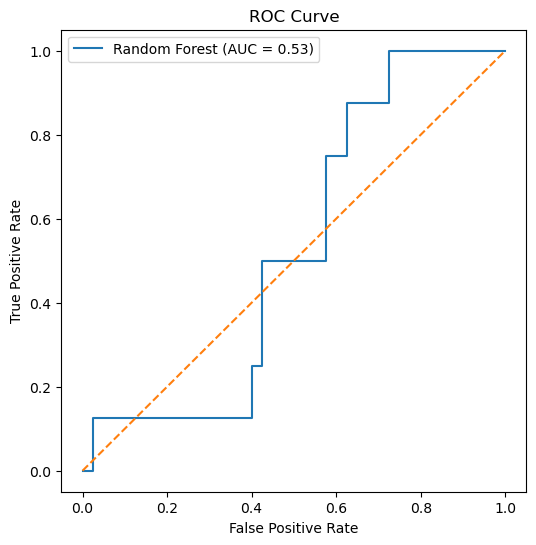

In [42]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='Random Forest (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve')
plt.legend(); plt.show()

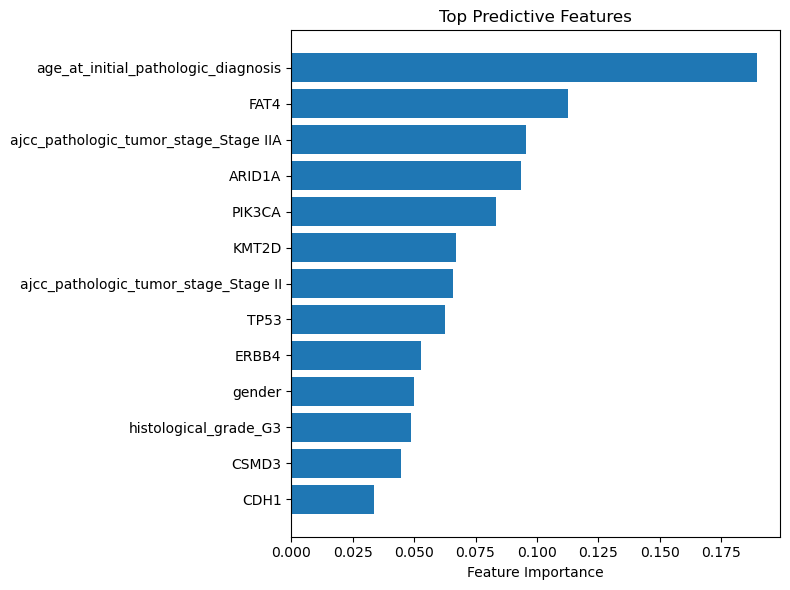

In [43]:
importances = best_rf.feature_importances_
feat_names = X_train.columns[sel.get_support()]
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices][::-1], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices][::-1])
plt.xlabel('Feature Importance'); plt.title('Top Predictive Features')
plt.tight_layout(); plt.show()
